# QC testing: Setting Hard QC thresholds

+ Plate 1: 96 samples(60/36), on MEGA kit v2, seq 15 sub-lib X 3 runs
+ Plate 2: 96 samples (88/8), on MEGA kit v2, seq 16 sub-lib X 3 runs
+ ~30 Billion reads per plate
+ Parse workflow has a low [doublet rate](https://support.parsebiosciences.com/hc/en-us/articles/360053107311-What-is-the-expected-doublet-rate#:~:text=Doublet%20rates%20are%20low%2C%20less,through%20the%20Whole%20Transcriptome%20workflow.): ~3% per 100K cells

***

Testing different filtering thresholds:

- Filter 1: Hard threshold for genes
    - min_genes_per_cell=500, 
    - max_genes_per_cell=6000,
    - min_counts_per_cell=500, 
    - min_cells_per_gene=5, 
    - min_cells_per_sample=10
    - Mito - 5%
    - Ribo - 5%
    - Filtering MT genes and MALAT1 removed
    - rm_doublets = False
    - rm_mad_outliers = False
- Filter 2: MAD thresholds per sample and doublet removal
    - Done in initial QC run
- Filter 3: Retain genes with at least `min_reads` in at least `min_samples` in the dataset
    - Discussed 100 samples, but indivdual plates have < 100 samples so applied n samples
 
***

In [1]:
# This cell is labelled 'paramters' to work with papermill remotely
# Papermill will overwite the default local plate value below with whatever is passed to 
# the -p flag in the snakerule shell script
#os.system("conda activate eqtl_study") use this locally if using VScode
plate = 'plate1'
plate = globals().get("plate")
print(f"Processing plate: {plate}")

Processing plate: plate1


In [2]:
# Import custom utility packages, lists and functions
import sys
import os
if os.path.exists('/scratch/'):
    root_dir = '/scratch/c.c1477909/eQTL_study_2025/'
else:
    root_dir = '/Users/darren/Desktop/eQTL_study_2025/'
        
sys.path.append(root_dir + 'workflow/scripts/')

from init_env import *
from anndata_utils import *
from gene_lists import *

# Set variables
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5]
batch_col = 'plate' # Should we set to plate and sample??
rm_doublets = False
rm_mad_outliers = False
run_filter_1 = False
run_filter_2 = False
run_filter_3 = True

# Load data

2025-01-14 16:24:21,989 - INFO - Plate variable detected: plate1
2025-01-14 16:24:21,990 - INFO - Processing plate: plate1



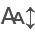

2025-01-14 16:24:22,014 - INFO - Script initialized. Root directory: /Users/darren/Desktop/eQTL_study_2025/
2025-01-14 16:24:22,015 - INFO - Parse directory: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/
2025-01-14 16:24:22,016 - INFO - Scanpy directory: /Users/darren/Desktop/eQTL_study_2025/results/03SCANPY/
2025-01-14 16:24:22,016 - INFO - Scanpy directory exists: True
2025-01-14 16:24:22,017 - INFO - plate_path set to: /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad
2025-01-14 16:24:22,018 - INFO - Loading data ...


Processing 1 plate(s) with downsampling to 4000 cells per plate.
Loading plate 1 from /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate1/all-sample/DGE_filtered/anndata.h5ad ...
Plate 1 dimensions: (861960, 65472)
Plate 1 matrix dimensions: (861960, 65472)
Only one plate processed; no need to find common genes.
AnnData object with n_obs × n_vars = 4000 × 65472
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden'
    var: 'gene_id', 'gene_name', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'norm10k'
    obsp: 'connectivities', 'distances'


In [3]:
# Initialize the environment and get all paths and logger
logger, root_dir, plate_path, scanpy_dir = initialize_env(plate)
logger.info("Loading data ...")

# Use the plate_path and scanpy_dir as needed
adata = load_and_dwnsmpl_data(None, plate_path)

In [4]:
adata.obs

sample species  gene_count  tscp_count  \
bc_wells                                                             
plate1_08_65_84__s1   sample_17936    hg38         944        1302   
plate1_61_54_18__s14  sample_12152    hg38         805        1002   
plate1_56_08_44__s11  sample_12993    hg38         878        1245   
plate1_23_77_89__s12  sample_14524    hg38         949        1308   
plate1_52_44_49__s13      17809_FC    hg38        1772        3238   
...                            ...     ...         ...         ...   
plate1_12_66_95__s10  sample_14812    hg38        1674        2614   
plate1_46_69_46__s11  sample_18372    hg38        2154        3738   
plate1_04_76_55__s14  sample_17671    hg38        2196        4621   
plate1_08_40_45__s12  sample_17936    hg38        1014        1427   
plate1_77_68_77__s5   sample_17086    hg38         311         347   

                      mread_count leiden  
bc_wells                                  
plate1_08_65_84__s1          2296      1  
plate1_61_54_18__s14         2229      2  
plate1_56_08_44__s11         2612      7  
plate1_23_77_89__s12         2683      2  
plate1_52_44_49__s13         6144     11  
...                           ...    ...  
plate1_12_66_95__s10         5530      4  
plate1_46_69_46__s11         7875      8  
plate1_04_76_55__s14        10949      2  
plate1_08_40_45__s12         3207      2  
plate1_77_68_77__s5           793     12  

[4000 rows x 6 columns]

# QC metadata

In [5]:
logger.info("Running QC ...")
adata.obs['sample'] = adata.obs['sample'].str.replace('sample_', '')
adata = adata[~adata.obs['sample'].str.endswith(tuple(['WGE', 'Hipp', 'Thal']))]
adata.obs['sublibrary'] = [x[1] for x in adata.obs.index.str.split('__s')] 
adata.obs['sample'].value_counts() # Cells per sample pre-filter

2025-01-14 16:25:48,423 - INFO - Running QC ...


sample
18372       105
11654        85
17048        81
17486        81
17936        74
           ... 
16972        18
11875        17
14521        17
17940        13
14611_FC      8
Name: count, Length: 73, dtype: int64

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

#plt.hist(adata.var['n_cells_by_counts'], bins=500)
#plt.xlabel('N cells expressing > 0')
#plt.ylabel('log(N genes)') # for visual clarity
#plt.axvline(2, color='red')
#plt.yscale('log') 

#sns.jointplot(
#   data=adata.obs,
#   x="log1p_total_counts",
#   y="log1p_n_genes_by_counts",
#   kind="hex",
#)
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate1_08_65_84__s1      17936    hg38         944        1302         2296   
plate1_61_54_18__s14     12152    hg38         805        1002         2229   
plate1_56_08_44__s11     12993    hg38         878        1245         2612   
plate1_23_77_89__s12     14524    hg38         949        1308         2683   
plate1_52_44_49__s13  17809_FC    hg38        1772        3238         6144   
...                        ...     ...         ...         ...          ...   
plate1_12_66_95__s10     14812    hg38        1674        2614         5530   
plate1_46_69_46__s11     18372    hg38        2154        3738         7875   
plate1_04_76_55__s14     17671    hg38        2196        4621        10949   
plate1_08_40_45__s12     17936    hg38        1014        1427         3207   
plate1_77_68_77__s5      17086    hg38         311         347          793   

                     leiden sublibrary  n_genes_by_counts  \
bc_wells                                                    
plate1_08_65_84__s1       1          1                944   
plate1_61_54_18__s14      2         14                805   
plate1_56_08_44__s11      7         11                878   
plate1_23_77_89__s12      2         12                949   
plate1_52_44_49__s13     11         13               1772   
...                     ...        ...                ...   
plate1_12_66_95__s10      4         10               1674   
plate1_46_69_46__s11      8         11               2154   
plate1_04_76_55__s14      2         14               2196   
plate1_08_40_45__s12      2         12               1014   
plate1_77_68_77__s5      12          5                311   

                      log1p_n_genes_by_counts  total_counts  ...  \
bc_wells                                                     ...   
plate1_08_65_84__s1                  6.851185   3559.717373  ...   
plate1_61_54_18__s14                 6.692084   3421.503072  ...   
plate1_56_08_44__s11                 6.778785   3412.934884  ...   
plate1_23_77_89__s12                 6.856462   3560.895969  ...   
plate1_52_44_49__s13                 7.480428   5253.755639  ...   
...                                       ...           ...  ...   
plate1_12_66_95__s10                 7.423568   5387.577424  ...   
plate1_46_69_46__s11                 7.675546   6614.996435  ...   
plate1_04_76_55__s14                 7.694848   5983.466249  ...   
plate1_08_40_45__s12                 6.922644   3861.785672  ...   
plate1_77_68_77__s5                  5.743003   1698.574119  ...   

                      pct_counts_in_top_500_genes  total_counts_mt  \
bc_wells                                                             
plate1_08_65_84__s1                     70.587154         0.000000   
plate1_61_54_18__s14                    78.089733         0.000000   
plate1_56_08_44__s11                    73.198313         0.000000   
plate1_23_77_89__s12                    70.018164         0.000000   
plate1_52_44_49__s13                    47.427850         0.000000   
...                                           ...              ...   
plate1_12_66_95__s10                    50.472040         0.000000   
plate1_46_69_46__s11                    45.600168        11.375179   
plate1_04_76_55__s14                    43.378663         0.000000   
plate1_08_40_45__s12                    67.999572        12.567894   
plate1_77_68_77__s5                    100.000000         0.000000   

                      log1p_total_counts_mt  pct_counts_mt  total_counts_ribo  \
bc_wells                                                                        
plate1_08_65_84__s1                0.000000       0.000000          12.386146   
plate1_61_54_18__s14               0.000000       0.000000           7.438129   
plate1_56_08_44__s11               0.000000       0.000000           5.913800   
p

In [7]:
adata.obs[['tscp_count', 'total_counts']] # Why the discrepancy? Duplicates? This is the filtered matrix??!!

tscp_count  total_counts
bc_wells                                      
plate1_08_65_84__s1         1302   3559.717373
plate1_61_54_18__s14        1002   3421.503072
plate1_56_08_44__s11        1245   3412.934884
plate1_23_77_89__s12        1308   3560.895969
plate1_52_44_49__s13        3238   5253.755639
...                          ...           ...
plate1_12_66_95__s10        2614   5387.577424
plate1_46_69_46__s11        3738   6614.996435
plate1_04_76_55__s14        4621   5983.466249
plate1_08_40_45__s12        1427   3861.785672
plate1_77_68_77__s5          347   1698.574119

[3138 rows x 2 columns]

2025-01-14 16:25:49,359 - INFO - Most exp genes ...


normalizing counts per cell
    finished (0:00:00)


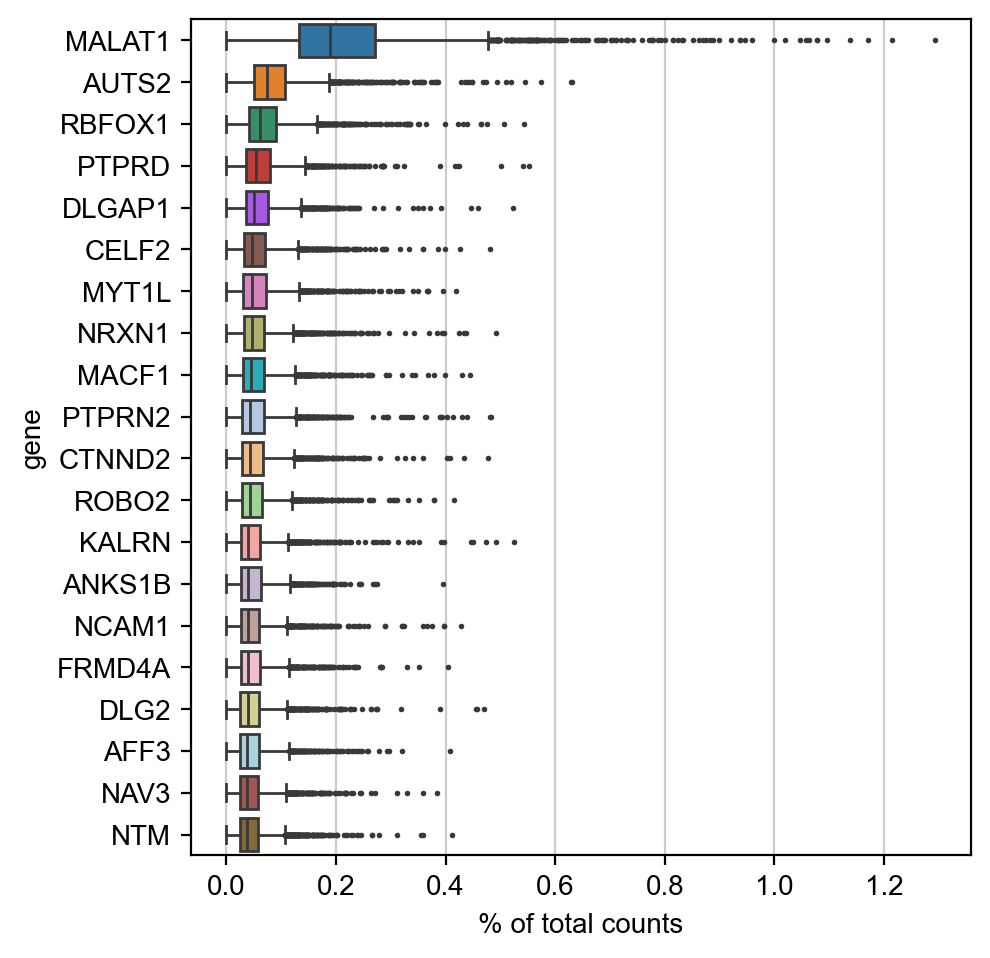

In [8]:
# Most expressed genes - Not such a big deal now?
logger.info("Most exp genes ...")
sc.pl.highest_expr_genes(adata, n_top=20)

In [9]:
# Filter 1
# - Remove cells with < 300 genes OR < 500 reads
# - Remove genes expressed in < 5 cells
# - Remove samples with fewer than 500 cells

#### NOTE: tscp_count != total_counts. Scanpy uses total_counts for filters. Check why these values don't match ####

In [10]:
if run_filter_1 is True:
    logger.info("Applying filter 1 ...")

    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='gene_count',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for gene per cell')
    plt.axhline(y = 300, color = 'r', linestyle = '-')
    plt.axhline(y = 6000, color = 'r', linestyle = '-') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for counts per cell')
    plt.axhline(y = 500, color = 'r', linestyle = '-')
    
    # 
    
    filter_anndata(
        adata, 
        min_genes_per_cell=500, 
        max_genes_per_cell=6000,
        min_counts_per_cell=500, 
        min_cells_per_gene=5, 
        min_cells_per_sample=10)
    adata.shape

In [11]:
#Filter 2 
if run_filter_2 is True:
    logger.info("Detecting MAD outliers ...")
    detect_mad_outliers_per_sample(
        adata,
        group_column="sample",       # Column in `adata.obs` to group by
        target_column="total_counts",  # Column to detect outliers
        threshold=3,                # Number of MADs for outlier detection
        log=False,                  # Whether to log-transform the data
        use_median=True             # Use median and MAD (or mean and SD)
    )
    
    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    
    # Overlay outlier cells with red dots
    outliers = adata.obs.loc[adata.obs['mad_outlier']]
    ax.scatter(
        x=outliers['sample'],  # X-coordinates (groupby value)
        y=outliers['total_counts'],  # Y-coordinates (outlier values)
        color='red',
        label='Outliers',
        s=10,
        alpha=0.8
    )


In [12]:
# Note this function includes mito and ribo gene removal so is always run
logger.info("Applying filter 2 ...") 
filter_cells_and_genes(adata, 5, 5, rm_doublets, rm_mad_outliers)

2025-01-14 16:25:50,053 - INFO - Applying filter 2 ...


Applying cell filters with thresholds: mito > 5%, ribo > 5%
Counts of outliers for removal:
  mito_gt_threshold: 0
  ribo_gt_threshold: 0
  is_outlier: 0
Dimensions before cell filter: (3138, 65472)
Dimensions after cell filter: (3138, 65472)
Applying gene filters: remove mitochondrial genes and MALAT1
Number of genes removed: 17
Dimensions after gene filter: (3138, 65455)


Filtered genes: 0 remain.


... storing 'sample' as categorical
... storing 'sublibrary' as categorical


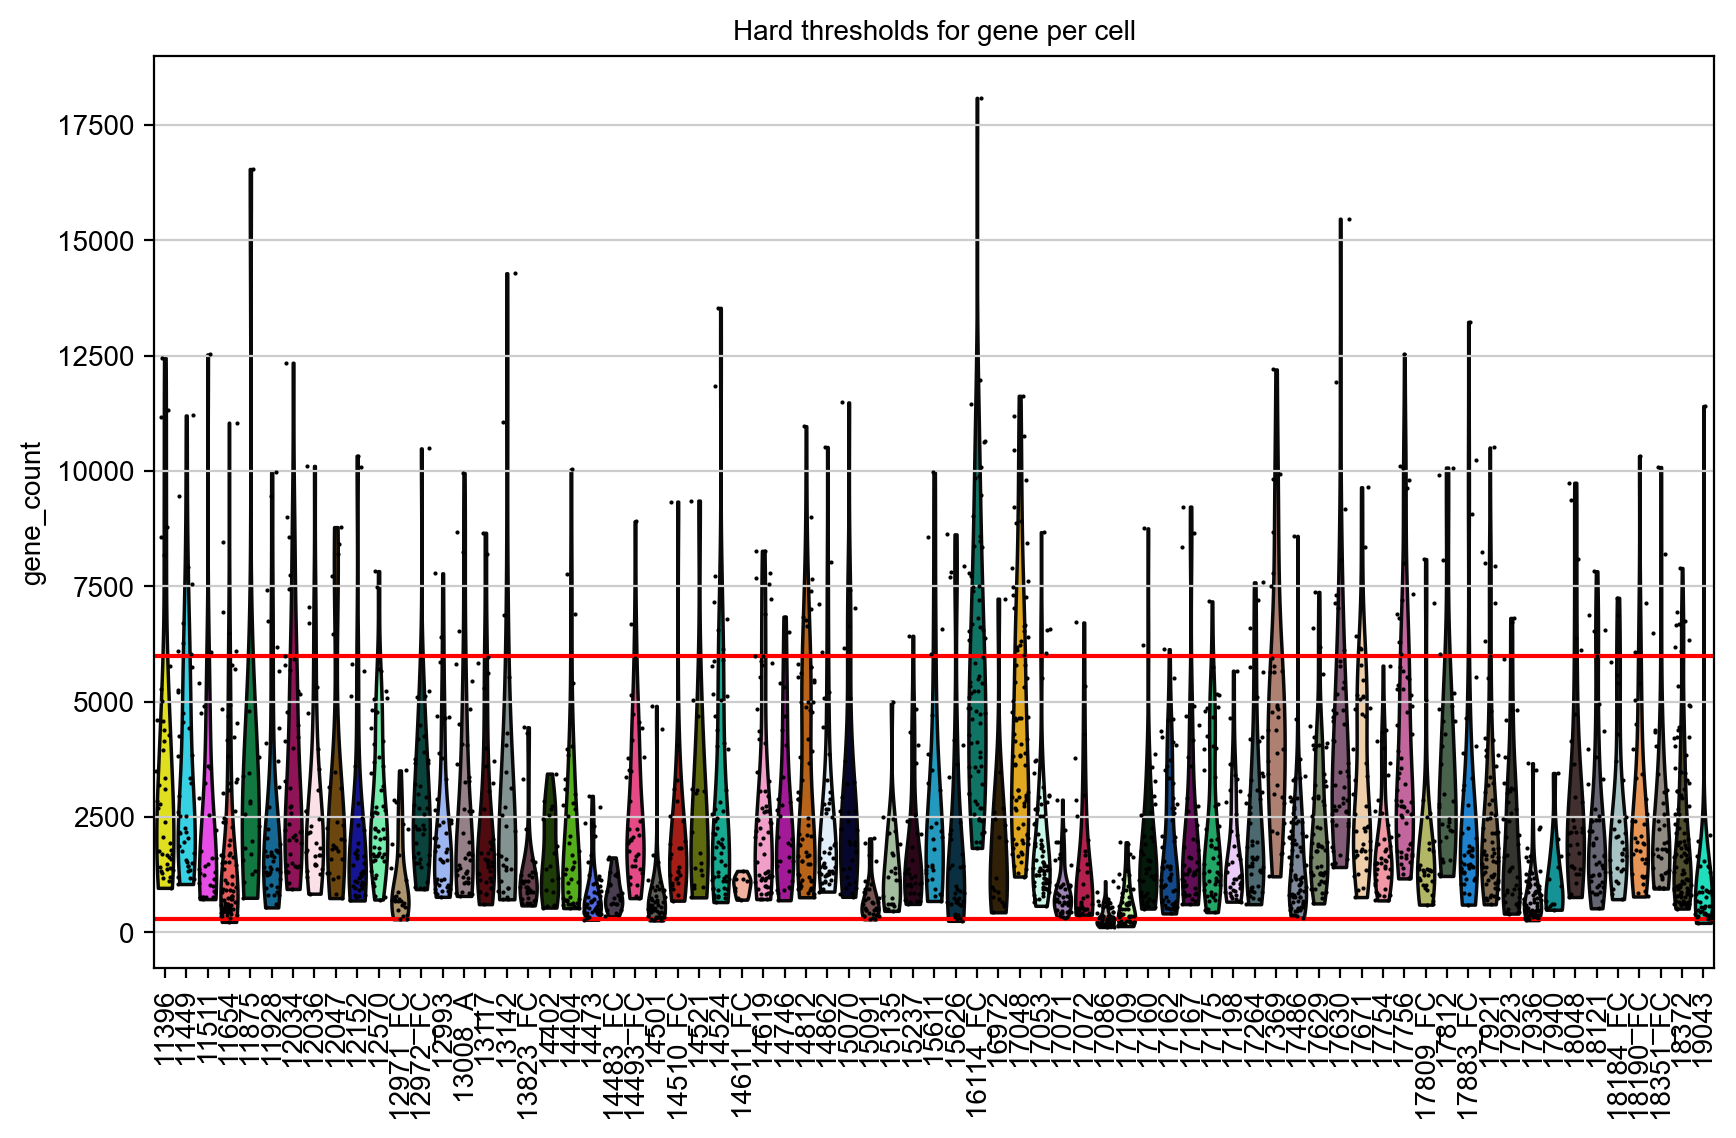

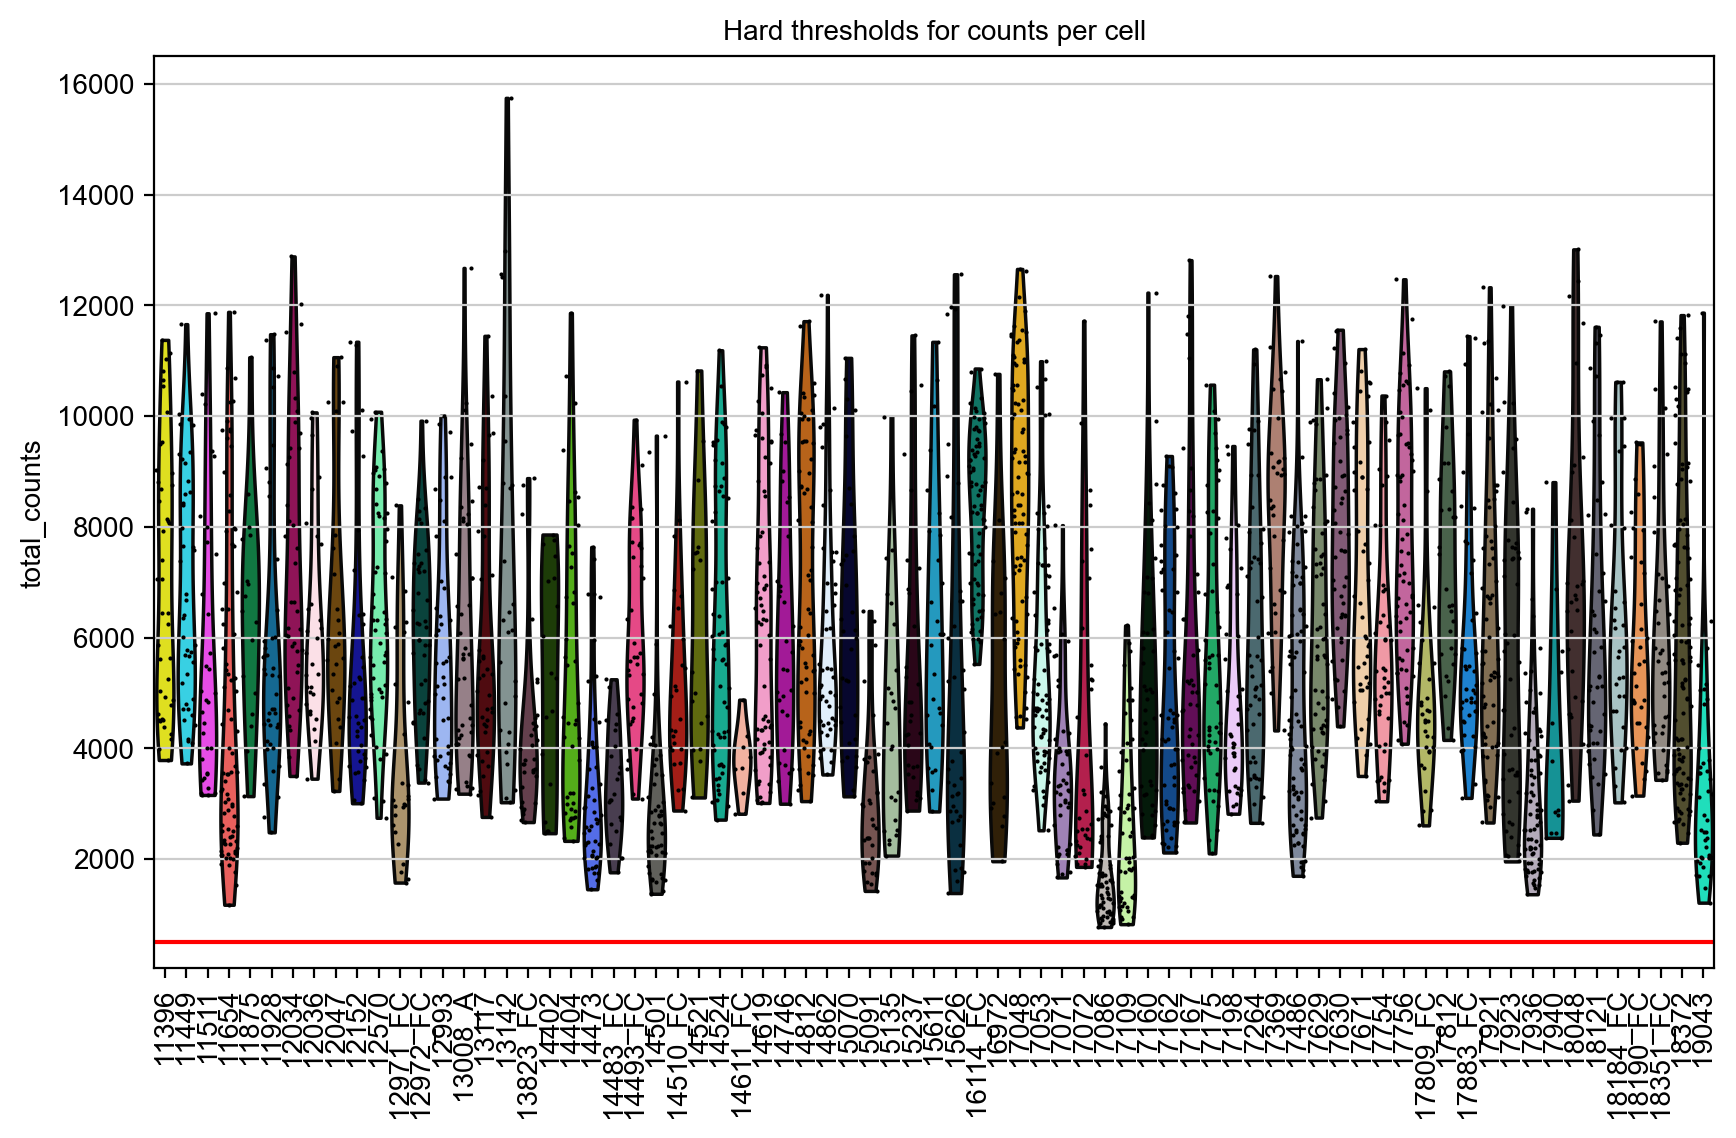

In [13]:
# Filter 3
if run_filter_3 is True:
    sample_num = adata.obs['sample'].nunique() # Note that the maximum number of samples will be < 100 per plate
    def filter_genes_by_read_count(adata, min_reads=10, min_samples=100, inplace=True):
        """
        Identifies genes with at least `min_reads` in at least `min_samples` in the dataset.
        
        Parameters:
        - adata: AnnData object containing gene expression data.
        - min_reads: Minimum number of reads required per cell/sample.
        - min_samples: Minimum number of samples/cells that must meet the `min_reads` threshold.
        - inplace: If True, filters genes directly in `adata`. If False, returns a mask.
    
        Returns:
        - If `inplace=True`: Modifies `adata` by retaining only the filtered genes.
        - If `inplace=False`: Returns a boolean mask of the genes that meet the criteria.
        """
        # Count the number of samples with at least `min_reads` for each gene
        gene_mask = (adata.X >= min_reads).sum(axis=0).A1 >= min_samples
    
        if inplace:
            # Subset the AnnData object to retain only the filtered genes
            adata._inplace_subset_var(gene_mask)
        else:
            # Return the mask for external usage
            return gene_mask
    
    filter_genes_by_read_count(adata, min_reads=10, min_samples=100)
    print(f"Filtered genes: {adata.n_vars} remain.")
    
    #gene_mask = filter_genes_by_read_count(adata, min_reads=10, min_samples=sample_num, inplace=False)
    #print(f"Number of genes meeting criteria: {gene_mask.sum()}")
    
    # Create the violin plot
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='gene_count',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for gene per cell')
    plt.axhline(y = 300, color = 'r', linestyle = '-')
    plt.axhline(y = 6000, color = 'r', linestyle = '-') 
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sc.pl.violin(
        adata,
        keys='total_counts',
        jitter=0.4,
        groupby='sample',
        rotation=90,
        size=1.5,
        ax=ax,
        show=False, 
        color='Red'
    )
    plt.title('Hard thresholds for counts per cell')
    plt.axhline(y = 500, color = 'r', linestyle = '-')


In [14]:
# Plot UMAP
def run_default_scanpy(ann_obj):

    sc.pp.normalize_total(ann_obj) # Norm to median total count
    sc.pp.log1p(ann_obj)
    sc.pp.highly_variable_genes(ann_obj, n_top_genes=2000, flavor="seurat_v3")
    sc.tl.pca(ann_obj, svd_solver='arpack')
    sc.pp.neighbors(ann_obj)
    sc.tl.leiden(ann_obj)
    sc.pl.umap(ann_obj, color=['leiden'])

run_default_scanpy(adata)

normalizing counts per cell
    finished (0:00:00)


ValueError: Found array with 0 feature(s) (shape=(3138, 0)) while a minimum of 1 is required.

In [ ]:
# Plot vlns
gene_sets = [
    ("general_genes", general_genes),
    ("pfc_features", pfc_features)
]

fig = plot_filtered_violin(
    adata, 
    gene_sets, 
    groupby_base="leiden", 
    resolutions=None, 
    clustering_algorithm="Leiden")
plt.show()  # Display the figure

In [ ]:
# Plot sample per cluster
# Function saves an excel file with the cell counts per sample per cluster 
# Extract sample and leiden cluster information from the AnnData object
fig = plot_and_save_cluster_percentages(
    adata=adata,
    output_dir = scanpy_dir,
    clustering_param="leiden"
)
plt.show() 

In [ ]:
# Final Dimesnsions
adata.shape

In [ ]:
# Cells per sample after filter
adata.obs['sample'].value_counts()

In [ ]:
# Final distributions per sample
# Create the violin plot
fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.violin(
    adata,
    keys='gene_count',
    jitter=0.4,
    groupby='sample',
    rotation=90,
    size=1.5,
    ax=ax,
    show=False, 
    color='Red'
)
plt.title('Final gene per cell')
plt.axhline(y = 300, color = 'r', linestyle = '-')
plt.axhline(y = 6000, color = 'r', linestyle = '-') 

fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.violin(
    adata,
    keys='total_counts',
    jitter=0.4,
    groupby='sample',
    rotation=90,
    size=1.5,
    ax=ax,
    show=False, 
    color='Red'
)
plt.title('Final counts per cell')
plt.axhline(y = 500, color = 'r', linestyle = '-')